# 08 · Scaling curves across capabilities

The headline validation: does each benchmark track model quality? Plot capability score vs a bad-to-good model ladder, with the null floor. The production version loads results JSON from `scripts/scaling` and `scripts/vlm_game`; this laptop-safe demo uses fixed example values so the plotting contract is executable anywhere.


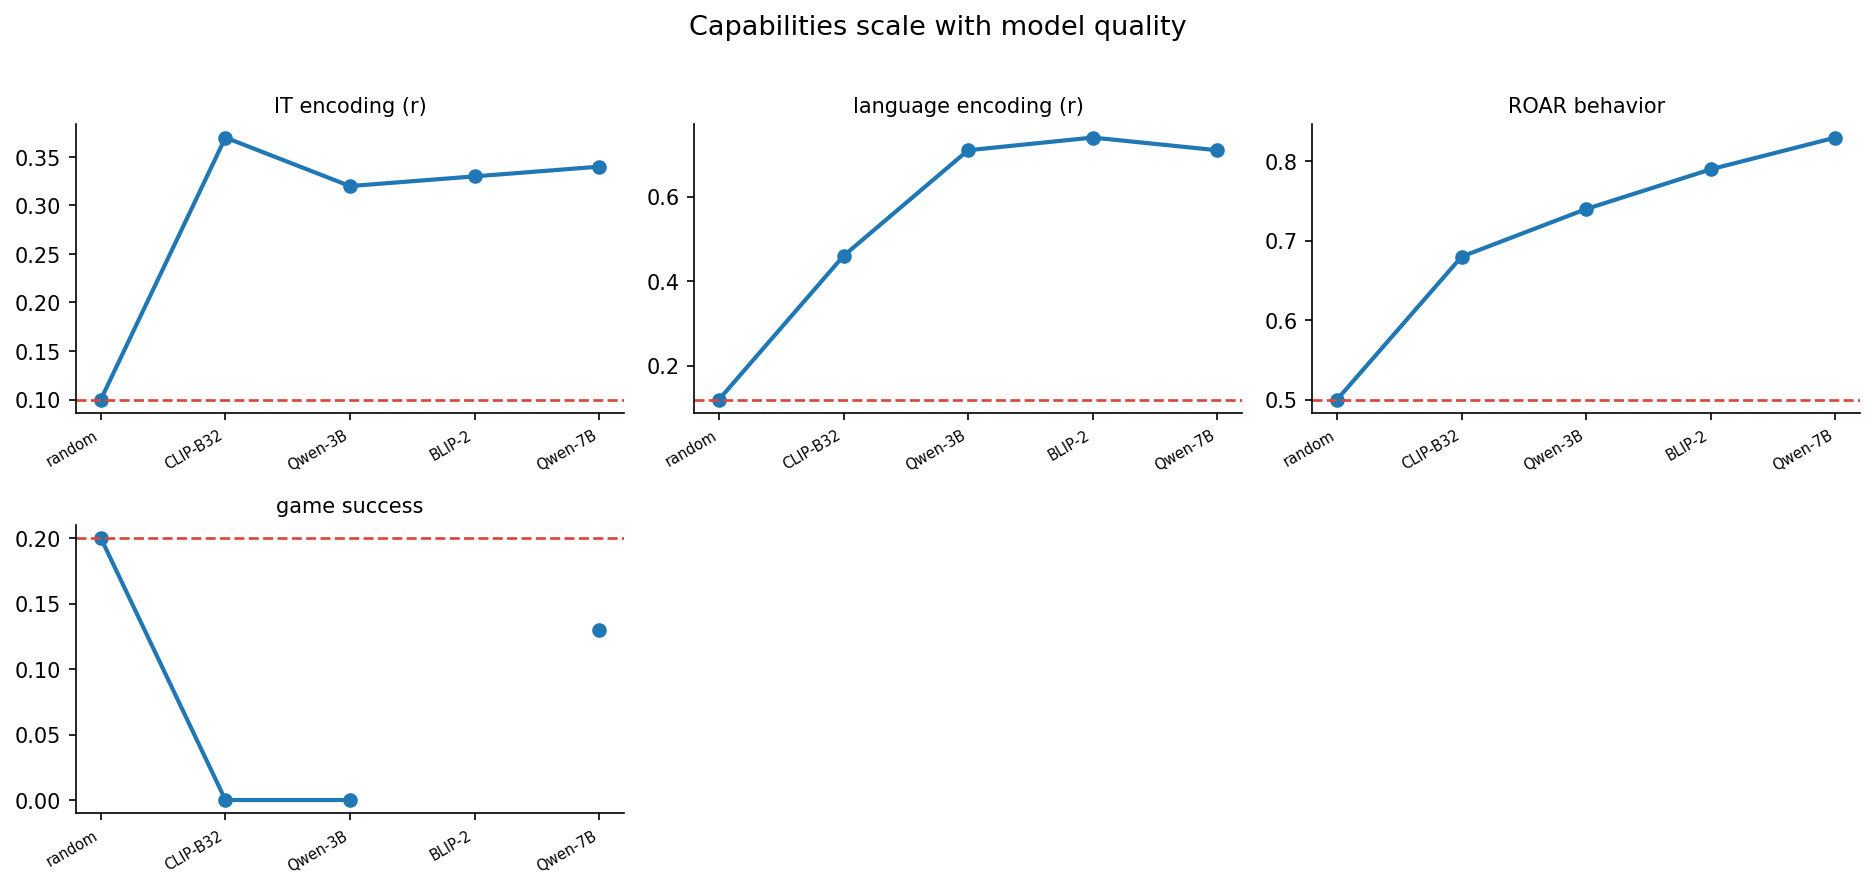

capabilities plotted: ['IT encoding (r)', 'language encoding (r)', 'ROAR behavior', 'game success']
ROAR clears null by final model: True
wrote plot: /var/folders/h6/g53mxg516n538136hh74630r0000gn/T/scaling_demo.png


In [1]:
import warnings
warnings.filterwarnings('ignore', message='xarray subclass Score should explicitly define __slots__', category=FutureWarning)

from pathlib import Path
import tempfile
from IPython.display import Image, display
from brainscore.visualization import scaling_curves_grid

models = ['random', 'CLIP-B32', 'Qwen-3B', 'BLIP-2', 'Qwen-7B']
scores = {
    'IT encoding (r)': [0.10, 0.37, 0.32, 0.33, 0.34],
    'language encoding (r)': [0.12, 0.46, 0.71, 0.74, 0.71],
    'ROAR behavior': [0.50, 0.68, 0.74, 0.79, 0.83],
    'game success': [0.20, 0.0, 0.0, float('nan'), 0.13],
}
floors = {
    'IT encoding (r)': 0.10,
    'language encoding (r)': 0.12,
    'ROAR behavior': 0.50,
    'game success': 0.20,
}
out_png = Path(tempfile.gettempdir()) / 'scaling_demo.png'
scaling_curves_grid(models, scores, null_floors=floors,
                    title='Capabilities scale with model quality',
                    out_png=str(out_png))
display(Image(str(out_png)))
print('capabilities plotted:', list(scores))
print('ROAR clears null by final model:', scores['ROAR behavior'][-1] > floors['ROAR behavior'])
print('wrote plot:', out_png)


**Reading it:** a capability whose curve climbs above its null floor and rises with model quality is measuring something real. A flat curve flags a saturated or noise-limited benchmark — surfaced honestly, not hidden.